# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze the relationship between Bitcoin market sentiment (Fear/Greed)
and trader behavior/performance on Hyperliquid.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

sentiment = pd.read_csv("../content/fear_greed_index.csv")
trades = pd.read_csv("../content/historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

## Dataset Overview

In [21]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values - Sentiment")
print(sentiment.isnull().sum())

print("\nMissing Values - Trades")
print(trades.isnull().sum())

print("Duplicate Rows in Sentiment:", sentiment.duplicated().sum())
print("Duplicate Rows in Trades:", trades.duplicated().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values - Sentiment
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values - Trades
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicate Rows in Sentiment: 0
Duplicate Rows in Trades: 0


## Data Cleaning & Date Alignment

In [22]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['time'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M")

trades['Date'] = trades['time'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

print(sentiment.head())
print(trades.head())

merged = trades.merge(
    sentiment,
    on='Date',
    how='left'
)

merged.head()

print(merged.shape)

    timestamp  value classification       date        Date
0  1517463000     30           Fear 2018-02-01  2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02  2018-02-02
2  1517635800     40           Fear 2018-02-03  2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04  2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.52

In [23]:
merged = trades.merge(
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

print(merged.head())
print(merged.shape)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

## Feature Engineering

In [24]:
merged['win'] = merged['Closed PnL'] > 0

merged['trade_size'] = merged['Size Tokens'].abs()

# merged['leverage_group'] = pd.cut(
#     merged['leverage'],
#     bins=[0,5,10,20,50,100],
#     labels=['0-5x','5-10x','10-20x','20-50x','50x+']
# )

In [25]:
daily_pnl = merged.groupby(
    ['Date','Account']
)['Closed PnL'].sum().reset_index()

In [26]:
win_rate = merged.groupby('Account')['win'].mean().reset_index()

win_rate.columns = ['account','win_rate']

In [27]:
trades_per_day = merged.groupby('Date').size().reset_index(name='trade_count')

## PnL by Market Sentiment

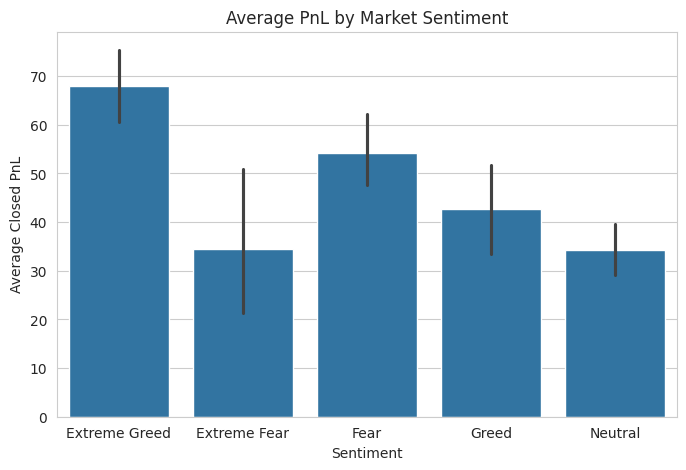

In [28]:
import os

plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")

plt.savefig("../content/pnl_by_sentiment.png")

plt.show()

### Insight
Average trader profitability differs across Fear and Greed market conditions, suggesting that overall market sentiment impacts trading outcomes.

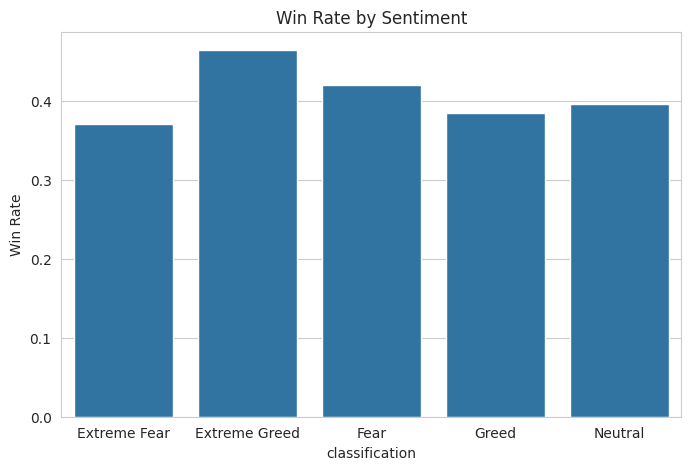

In [29]:
win_sentiment = merged.groupby('classification')['win'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=win_sentiment,
    x='classification',
    y='win'
)

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")

plt.savefig("../content/winrate_sentiment.png")

plt.show()

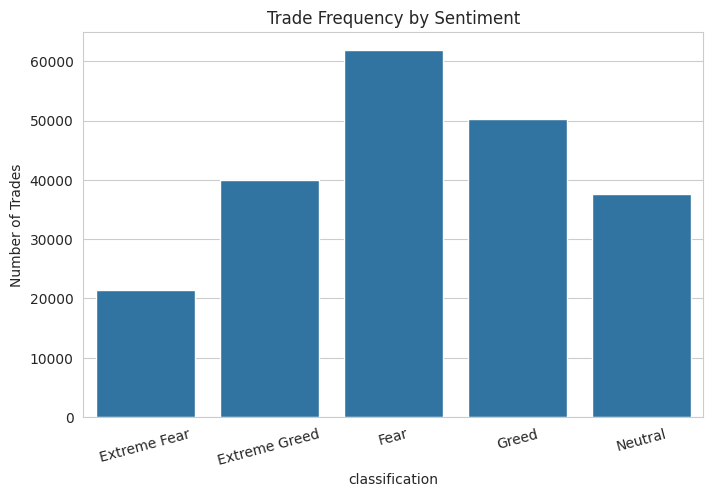

In [30]:
trade_freq_sentiment = merged.groupby(
    'classification'
).size().reset_index(name='trade_count')

plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_freq_sentiment,
    x='classification',
    y='trade_count'
)

plt.title("Trade Frequency by Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=15)

plt.show()

### Insight
Trade frequency appears to vary with market sentiment, suggesting that traders adjust their activity levels based on prevailing market conditions. For example, during 'Fear' or 'Extreme Fear' periods, there might be fewer trades, while 'Greed' or 'Extreme Greed' could see increased activity.

## Long/Short Bias by Market Sentiment

In [31]:
long_short_bias = merged.groupby(['classification', 'Side']).size().unstack(fill_value=0)
long_short_bias['long_short_ratio'] = long_short_bias['BUY'] / long_short_bias['SELL']
long_short_bias = long_short_bias.reset_index()

display(long_short_bias)

Side,classification,BUY,SELL,long_short_ratio
0,Extreme Fear,10935,10465,1.044912
1,Extreme Greed,17940,22052,0.813532
2,Fear,30270,31567,0.958913
3,Greed,24576,25727,0.955261
4,Neutral,18969,18717,1.013464


/tmp/ipykernel_743/1699558494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


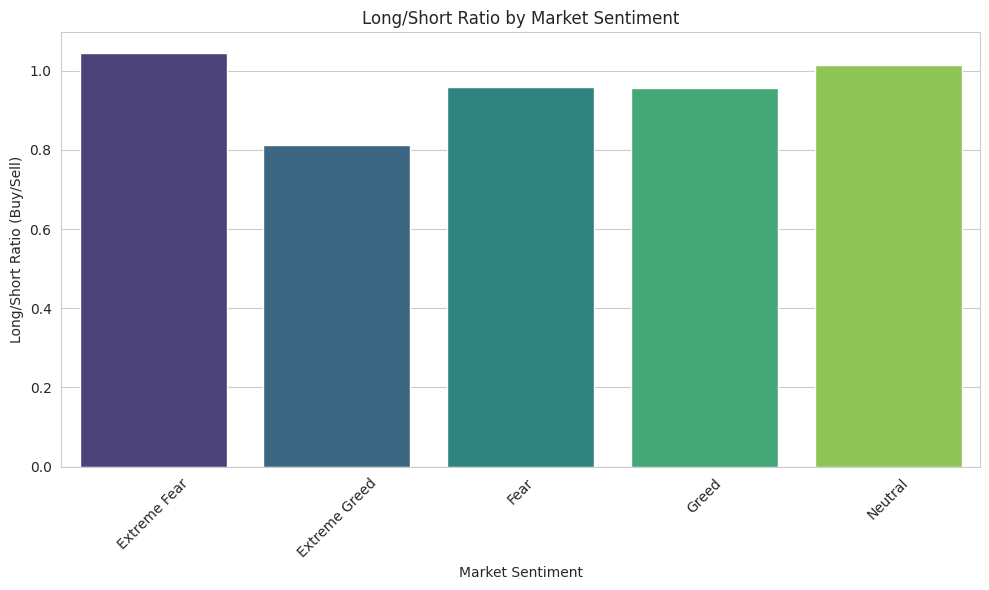

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=long_short_bias,
    x='classification',
    y='long_short_ratio',
    palette='viridis'
)
plt.title('Long/Short Ratio by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Long/Short Ratio (Buy/Sell)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../content/long_short_ratio_sentiment.png")
plt.show()

### Insight
The long/short ratio by sentiment provides insights into directional biases of traders. A ratio greater than 1 indicates a prevalence of buy trades (long positions), while a ratio less than 1 suggests more sell trades (short positions). This helps to understand if traders lean bullish or bearish under different market sentiments.

## Average Trade Size by Market Sentiment

In [33]:
average_trade_size_sentiment = merged.groupby('classification')['trade_size'].mean().reset_index()

display(average_trade_size_sentiment)

,classification,trade_size
0,Extreme Fear,1675.893319
1,Extreme Greed,8832.415746
2,Fear,2992.641845
3,Greed,4715.327756
4,Neutral,4383.368714


/tmp/ipykernel_743/2440724824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


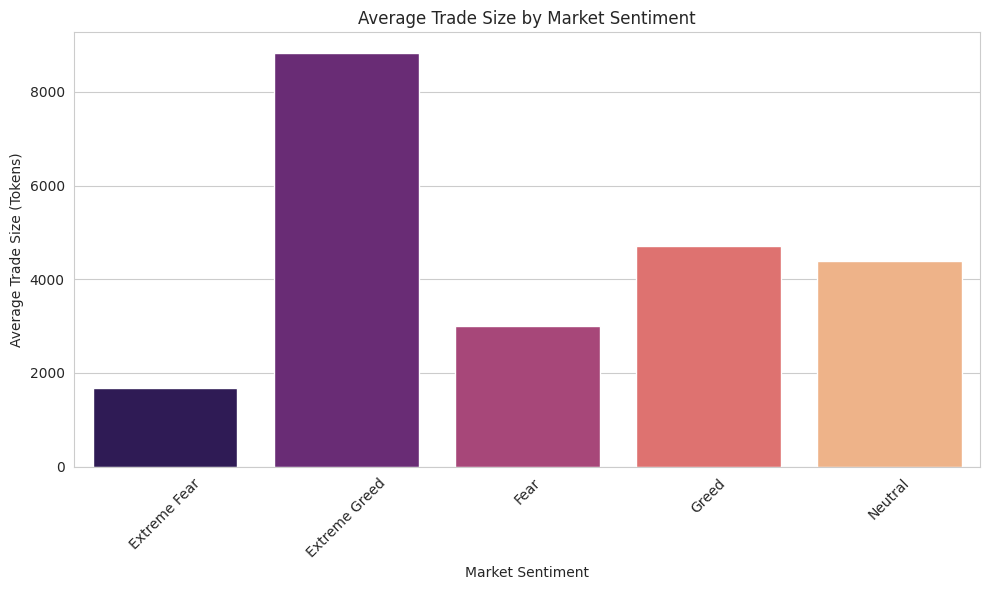

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=average_trade_size_sentiment,
    x='classification',
    y='trade_size',
    palette='magma'
)
plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size (Tokens)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../content/avg_trade_size_sentiment.png")
plt.show()

### Insight
The average trade size by market sentiment can reveal how confidently or cautiously traders are placing their trades. Larger average trade sizes during certain sentiments might indicate higher conviction, while smaller sizes could suggest a more conservative approach or uncertainty.

#Frequent vs Infrequent Traders

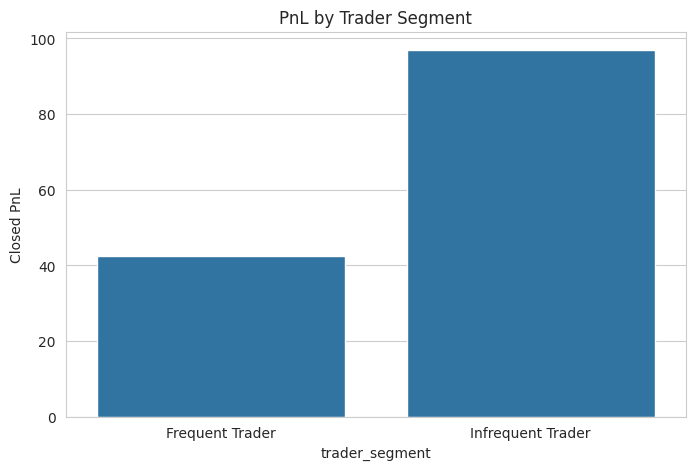

In [36]:
trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

frequent_traders = trade_counts[
    trade_counts > threshold
].index

merged['trader_segment'] = merged['Account'].apply(
    lambda x: 'Frequent Trader'
    if x in frequent_traders
    else 'Infrequent Trader'
)

# Compare Segment Performance
segment_performance = merged.groupby(
    'trader_segment'
)['Closed PnL'].mean().reset_index()

segment_performance

# Visualize Segment Performance
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_performance,
    x='trader_segment',
    y='Closed PnL'
)

plt.title("PnL by Trader Segment")

plt.show()

### Insight
Infrequent traders, on average, tend to have a higher 'Closed PnL' compared to frequent traders. This suggests that a more selective or less active trading approach might be correlated with better profitability.

#Insight
1. Average trader profitability differs across Fear and Greed market conditions, suggesting that overall market sentiment impacts trading outcomes.
2. Trade frequency appears to vary with market sentiment, suggesting that traders adjust their activity levels based on prevailing market conditions. For example, during 'Fear' or 'Extreme Fear' periods, there might be fewer trades, while 'Greed' or 'Extreme Greed' could see increased activity.
3. The long/short ratio by sentiment provides insights into directional biases of traders. A ratio greater than 1 indicates a prevalence of buy trades (long positions), while a ratio less than 1 suggests more sell trades (short positions). This helps to understand if traders lean bullish or bearish under different market sentiments.
4. The average trade size by market sentiment can reveal how confidently or cautiously traders are placing their trades. Larger average trade sizes during certain sentiments might indicate higher conviction, while smaller sizes could suggest a more conservative approach or uncertainty.
5. Infrequent traders, on average, tend to have a higher 'Closed PnL' compared to frequent traders. This suggests that a more selective or less active trading approach might be correlated with better profitability.



# Strategy Recommendations

## Strategy 1
Reduce leverage exposure during Fear periods to minimize downside volatility.

## Strategy 2
Momentum-oriented traders may increase activity selectively during Greed regimes where market direction appears stronger.